## The cosine similarity based on Morgan Fingerprints

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### load precomputed Morgan Fingerprints

In [2]:
df = pd.read_parquet('molecular_descriptors_raw_models_.parquet')

In [3]:
df

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,ChyLine_l2-4_c:[nH]:c,ChyLine_l2-4_[nH]:cC=C,ChyLine_l2-4_[nH]:c:c:c,ChyLine_l2-4_c:[nH]:c:c,ChyLine_l2-4_[nH]:c:c,ChyLine_l2-4_[nH]:c,ChyLine_l2-4_c:[nH]:cC,ChyLine_l2-4_c:cOc,ChyLine_l2-4_cOc,ChyLine_l2-4_cCCC
0,21.096774,5.806774,3.096774,6.451613,154.935746,83.174801,1.660974,5.923665,3.939068,7.356725,...,0,0,0,0,0,0,0,0,0,0
1,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0,0,0,0,0,0,0,0,0,0
2,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0,0,0,0,0,0,0,0,0,0
3,22.000000,5.860000,3.142857,6.857143,153.799230,86.861521,1.707574,5.980396,4.190476,7.395751,...,0,0,0,0,0,0,0,0,0,0
4,26.400000,6.438830,3.433333,10.000000,156.786781,104.641286,1.662128,6.517330,7.696296,7.908921,...,0,0,0,0,0,0,0,0,0,0
5,26.400000,6.438830,3.433333,10.000000,156.786781,104.641286,1.662128,6.517330,7.696296,7.908921,...,0,0,0,0,0,0,0,0,0,0
6,26.400000,6.438830,3.433333,10.000000,156.786781,104.641286,1.662128,6.517330,7.696296,7.908921,...,0,0,0,0,0,0,0,0,0,0
7,65.714286,5.955271,3.321429,7.109543,152.179524,314.848419,2.023927,6.120454,4.151605,7.525876,...,0,0,0,0,0,0,0,0,0,0
8,21.096774,5.806774,3.096774,6.451613,154.935746,83.174801,1.660974,5.923665,3.939068,7.356725,...,0,0,0,0,0,0,0,0,0,0
9,18.111111,5.800000,2.444444,4.777778,162.343794,70.887638,1.367313,5.875061,4.376543,7.406665,...,0,0,0,0,0,0,0,0,0,0


In [4]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Separate columns to standardize and those to keep as is
cols_to_standardize = [col for col in df.columns if "C_FP_" not in col]
cols_to_keep = [col for col in df.columns if "C_FP_" in col]


# Keep the other columns as is
df_unchanged = df[cols_to_keep]

# Remove columns that are entirely zeros
df_unchanged = df_unchanged.loc[:, (df_unchanged != 0).any(axis=0)]

# Ensure original column order
df_final = df_unchanged

# Compute cosine similarity matrix between rows
similarity_matrix = cosine_similarity(df_final.values)

# Convert similarity matrix back to DataFrame for easier interpretation (optional)
similarity_df = pd.DataFrame(similarity_matrix, index=df_final.index, columns=df_final.index)
print(similarity_df)

# Calculate overall average similarity excluding self-similarity
np.fill_diagonal(similarity_matrix, np.nan)
overall_similarity = np.nanmean(similarity_matrix)
print(f"Overall average similarity in dataset: {overall_similarity:.4f}")

          0         1         2         3         4         5         6   \
0   1.000000  0.926338  0.956082  0.932701  0.947972  0.931780  0.918633   
1   0.926338  1.000000  0.946494  0.970412  0.932263  0.947534  0.972058   
2   0.956082  0.946494  1.000000  0.945756  0.965239  0.943893  0.932335   
3   0.932701  0.970412  0.945756  1.000000  0.937905  0.960369  0.962340   
4   0.947972  0.932263  0.965239  0.937905  1.000000  0.963312  0.944449   
5   0.931780  0.947534  0.943893  0.960369  0.963312  1.000000  0.960170   
6   0.918633  0.972058  0.932335  0.962340  0.944449  0.960170  1.000000   
7   0.962002  0.939805  0.973154  0.945756  0.965239  0.943893  0.932335   
8   0.979112  0.914538  0.932402  0.932701  0.924566  0.925769  0.906968   
9   0.596657  0.569826  0.555630  0.576679  0.553197  0.576481  0.567259   
10  0.944487  0.963641  0.958879  0.964812  0.950444  0.957467  0.955216   
11  0.935243  0.975036  0.949217  0.967524  0.940875  0.953145  0.966460   
12  0.932402

In [5]:
df_final

,C_FP_1,C_FP_28,C_FP_48,C_FP_68,C_FP_80,C_FP_84,C_FP_91,C_FP_96,C_FP_99,C_FP_102,...,C_FP_1970,C_FP_1977,C_FP_1986,C_FP_1991,C_FP_1999,C_FP_2015,C_FP_2016,C_FP_2033,C_FP_2038,C_FP_2043
0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Find minimal similarity value (excluding diagonal)
min_similarity = np.nanmin(similarity_matrix)

print(f"Minimal similarity between any two rows: {min_similarity:.4f}")
# Find maximal similarity value (excluding diagonal)
min_similarity = np.nanmax(similarity_matrix)

print(f"Maximal similarity between any two rows: {min_similarity:.4f}")

Minimal similarity between any two rows: 0.4520
Maximal similarity between any two rows: 0.9831


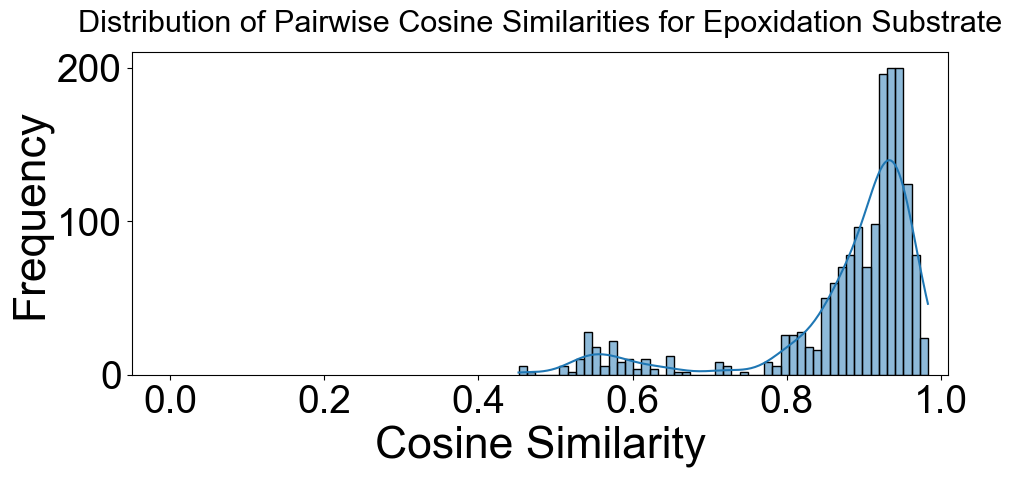

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Remove diagonal values (self-similarity = 1)
np.fill_diagonal(similarity_matrix, np.nan)

# Flatten the matrix and remove nan values to get pairwise similarities
sim_values = similarity_matrix.flatten()
sim_values = sim_values[~np.isnan(sim_values)]

# Set a clean font for better readability
plt.rcParams['font.family'] = 'Arial'  # Or 'Helvetica', 'sans-serif', etc.

# Create figure with specified size
plt.figure(figsize=(10, 5))

# Plot the distribution using seaborn
sns.histplot(sim_values, bins=50, kde=True)

# Customize font sizes for better visibility
plt.title('Distribution of Pairwise Cosine Similarities for Epoxidation Substrate', fontsize=22, pad=15)
plt.xlabel('Cosine Similarity', fontsize=32)
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.xlim(-0.05)
plt.ylabel('Frequency', fontsize=32)
plt.tick_params(axis='both', which='major', labelsize=28)  # Larger tick labels

# Adjust layout to prevent clipping
plt.tight_layout(pad=1.5)  # Add padding to avoid text cutoff

# Save to file with high DPI and tight bounding box
plt.savefig('cosine_similarities_II.svg', bbox_inches='tight', format='svg', dpi=300)

# Show the plot (optional, comment out if only saving)
plt.show()

# Close figure to free memory
plt.close()